# Data Cleaning
This notebook prepares the data for processing by removing irrelevant features, handling missing values, reducing redundency of data .

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

In [2]:
sys.path.append(os.path.abspath("C:/Dev/Projects/EDA-Portfolio/House-Prices-Dataset/src"))
os.listdir("C:/Dev/Projects/EDA-Portfolio/House-Prices-Dataset/src")

['utils.py', '__pycache__']

In [3]:
df=pd.read_csv('C:/Dev/Projects/EDA-Portfolio/House-Prices-Dataset/Data/raw/train.csv')
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [4]:
from utils import data_audit

audit=data_audit(df)
audit.head(10)

,Data Type,Missing Values,Unique Values,Percentage Missing
PoolQC,str,1453,3,99.520548
MiscFeature,str,1406,4,96.301370
Alley,str,1369,2,93.767123
Fence,str,1179,4,80.753425
MasVnrType,str,872,3,59.726027
FireplaceQu,str,690,5,47.260274
LotFrontage,float64,259,110,17.739726
GarageQual,str,81,5,5.547945
GarageFinish,str,81,3,5.547945
GarageType,str,81,6,5.547945


In [5]:
high_missing=audit[audit['Percentage Missing']>80]
high_missing

,Data Type,Missing Values,Unique Values,Percentage Missing
PoolQC,str,1453,3,99.520548
MiscFeature,str,1406,4,96.301370
Alley,str,1369,2,93.767123
Fence,str,1179,4,80.753425


Columns with high missing value percentage contribut very little in the data analysis and model processing thus drop the columns with highest missing percentage in the data .

In [6]:
cols_to_drop=high_missing.index
cols_to_drop

Index(['PoolQC', 'MiscFeature', 'Alley', 'Fence'], dtype='str')

In [7]:
df=df.drop(columns=cols_to_drop)
df.shape

(1460, 77)

In [8]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns
cat_cols=df.select_dtypes(include=["object"]).columns
print('Numerical Columns:',len(num_cols))
print('Categorical Columns:',len(cat_cols))

Numerical Columns: 38
Categorical Columns: 39


C:\Users\kasir\AppData\Local\Temp\ipykernel_2480\3715675778.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include=["object"]).columns


Numerical features are filled with median values of the respective features values to reduce overall impact of outliers

In [9]:
for col in num_cols:
    df[col]=df[col].fillna(df[col].median())

Categorical Columns are filled with the word 'None' in place of missing values to indicate the absence of the value

In [10]:
for col in cat_cols:
    df[col]=df[col].fillna('None')

In [11]:
df.isnull().sum().sum()

np.int64(0)

Sale Price distribution is right-skwed. Applying log-transform  help normalize the distribution and improves model performance

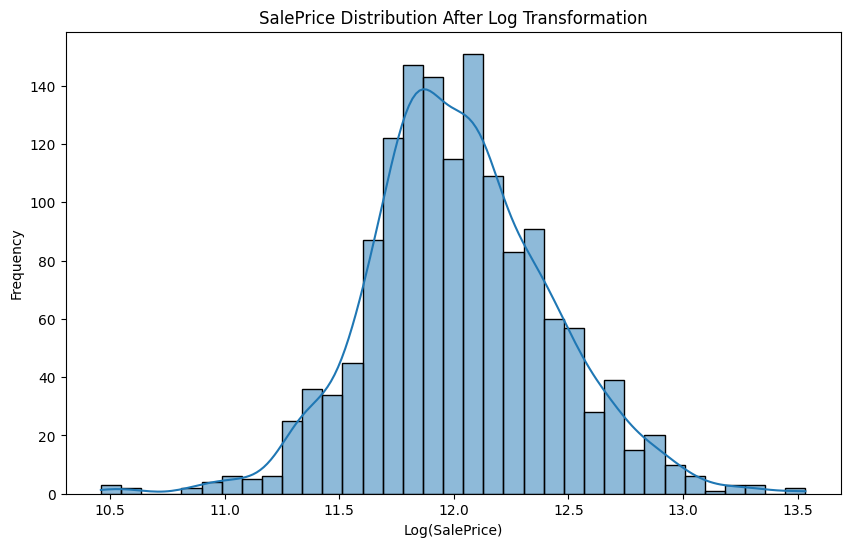

In [12]:
df['SalePrice']=np.log1p(df['SalePrice'])
plt.figure(figsize=(10,6))
sns.histplot(df['SalePrice'], kde=True)
plt.title('SalePrice Distribution After Log Transformation')
plt.xlabel('Log(SalePrice)')
plt.ylabel('Frequency')
plt.show()

In [13]:
df.to_csv('C:/Dev/Projects/EDA-Portfolio/House-Prices-Dataset/Data/processed/cleaned_train.csv', index=False)